# Packages

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import transformers
from torch.optim import AdamW

from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
import torch

import numpy as np
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from matplotlib import rc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
from textwrap import wrap

from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set(style='whitegrid', palette='muted', font_scale=1.2)

COLORS_PALETTE = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]

sns.set_palette(sns.color_palette(COLORS_PALETTE))

rcParams['figure.figsize'] = 12, 8

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

# EDA

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/ImdbDataset/IMDB Dataset.csv'
df = pd.read_csv(file_path)
df.shape

(50000, 2)

Any missing values?

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


No missing values. Do we have class imbalance?

In [ ]:
df.review[0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [ ]:
def to_sentiment(rating):
  rating = str(rating)
  if rating == 'positive':
    return 0
  else:
    return 1

df['sentiment_score'] = df.sentiment.apply(to_sentiment)

Text(0.5, 0, 'Sentiment')

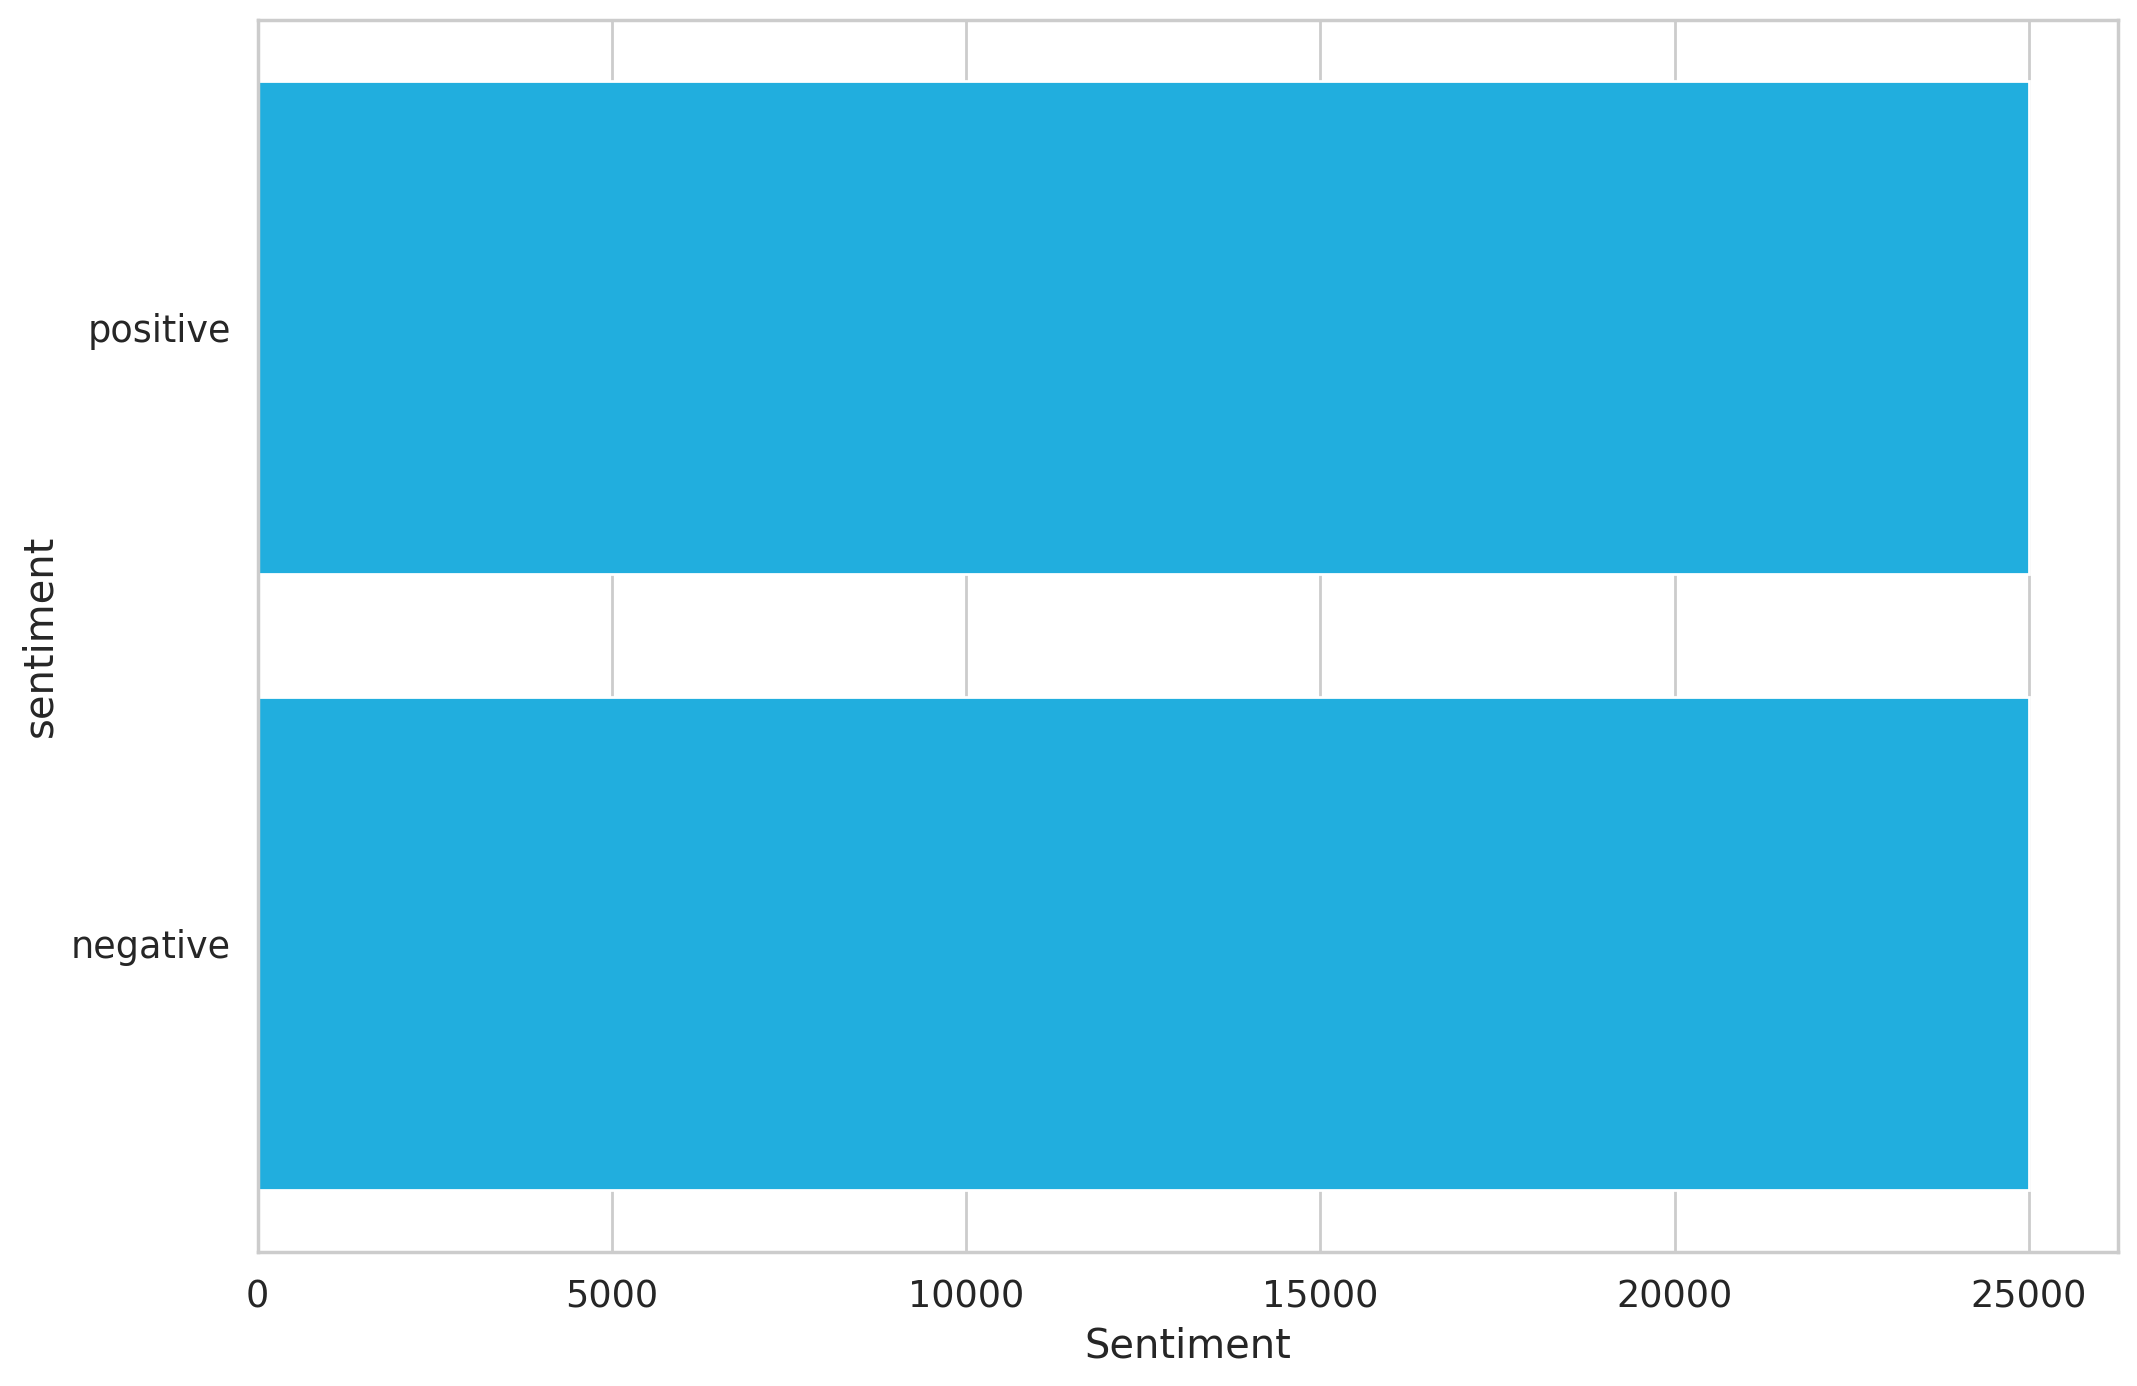

In [ ]:
sns.countplot(df.sentiment)
plt.xlabel('Sentiment')

The count plot shows that the dataset is balanced and have no missing values.

# Data Preprocessing

In [ ]:
PRE_TRAINED_MODEL_NAME = 'bert-base-cased'

In [ ]:
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
sample_txt = 'I want to learn how to do sentiment analysis using BERT and tokenizer.'

In [ ]:
encoding = tokenizer.encode_plus(
  sample_txt,
  max_length=32,
  add_special_tokens=True,
  return_token_type_ids=False,
  padding='max_length',
  return_attention_mask=True,
  return_tensors='pt',
  truncation = True
)

encoding.keys()

KeysView({'input_ids': tensor([[  101,   146,  1328,  1106,  3858,  1293,  1106,  1202, 17024,  3622,
          1606,   139,  9637,  1942,  1105, 22559, 17260,   119,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])})

In [ ]:
token_lens = []

for txt in df.review:
  tokens = tokenizer.encode(txt, max_length=512, truncation=True)
  token_lens.append(len(tokens))

/tmp/ipython-input-3638548306.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(token_lens)


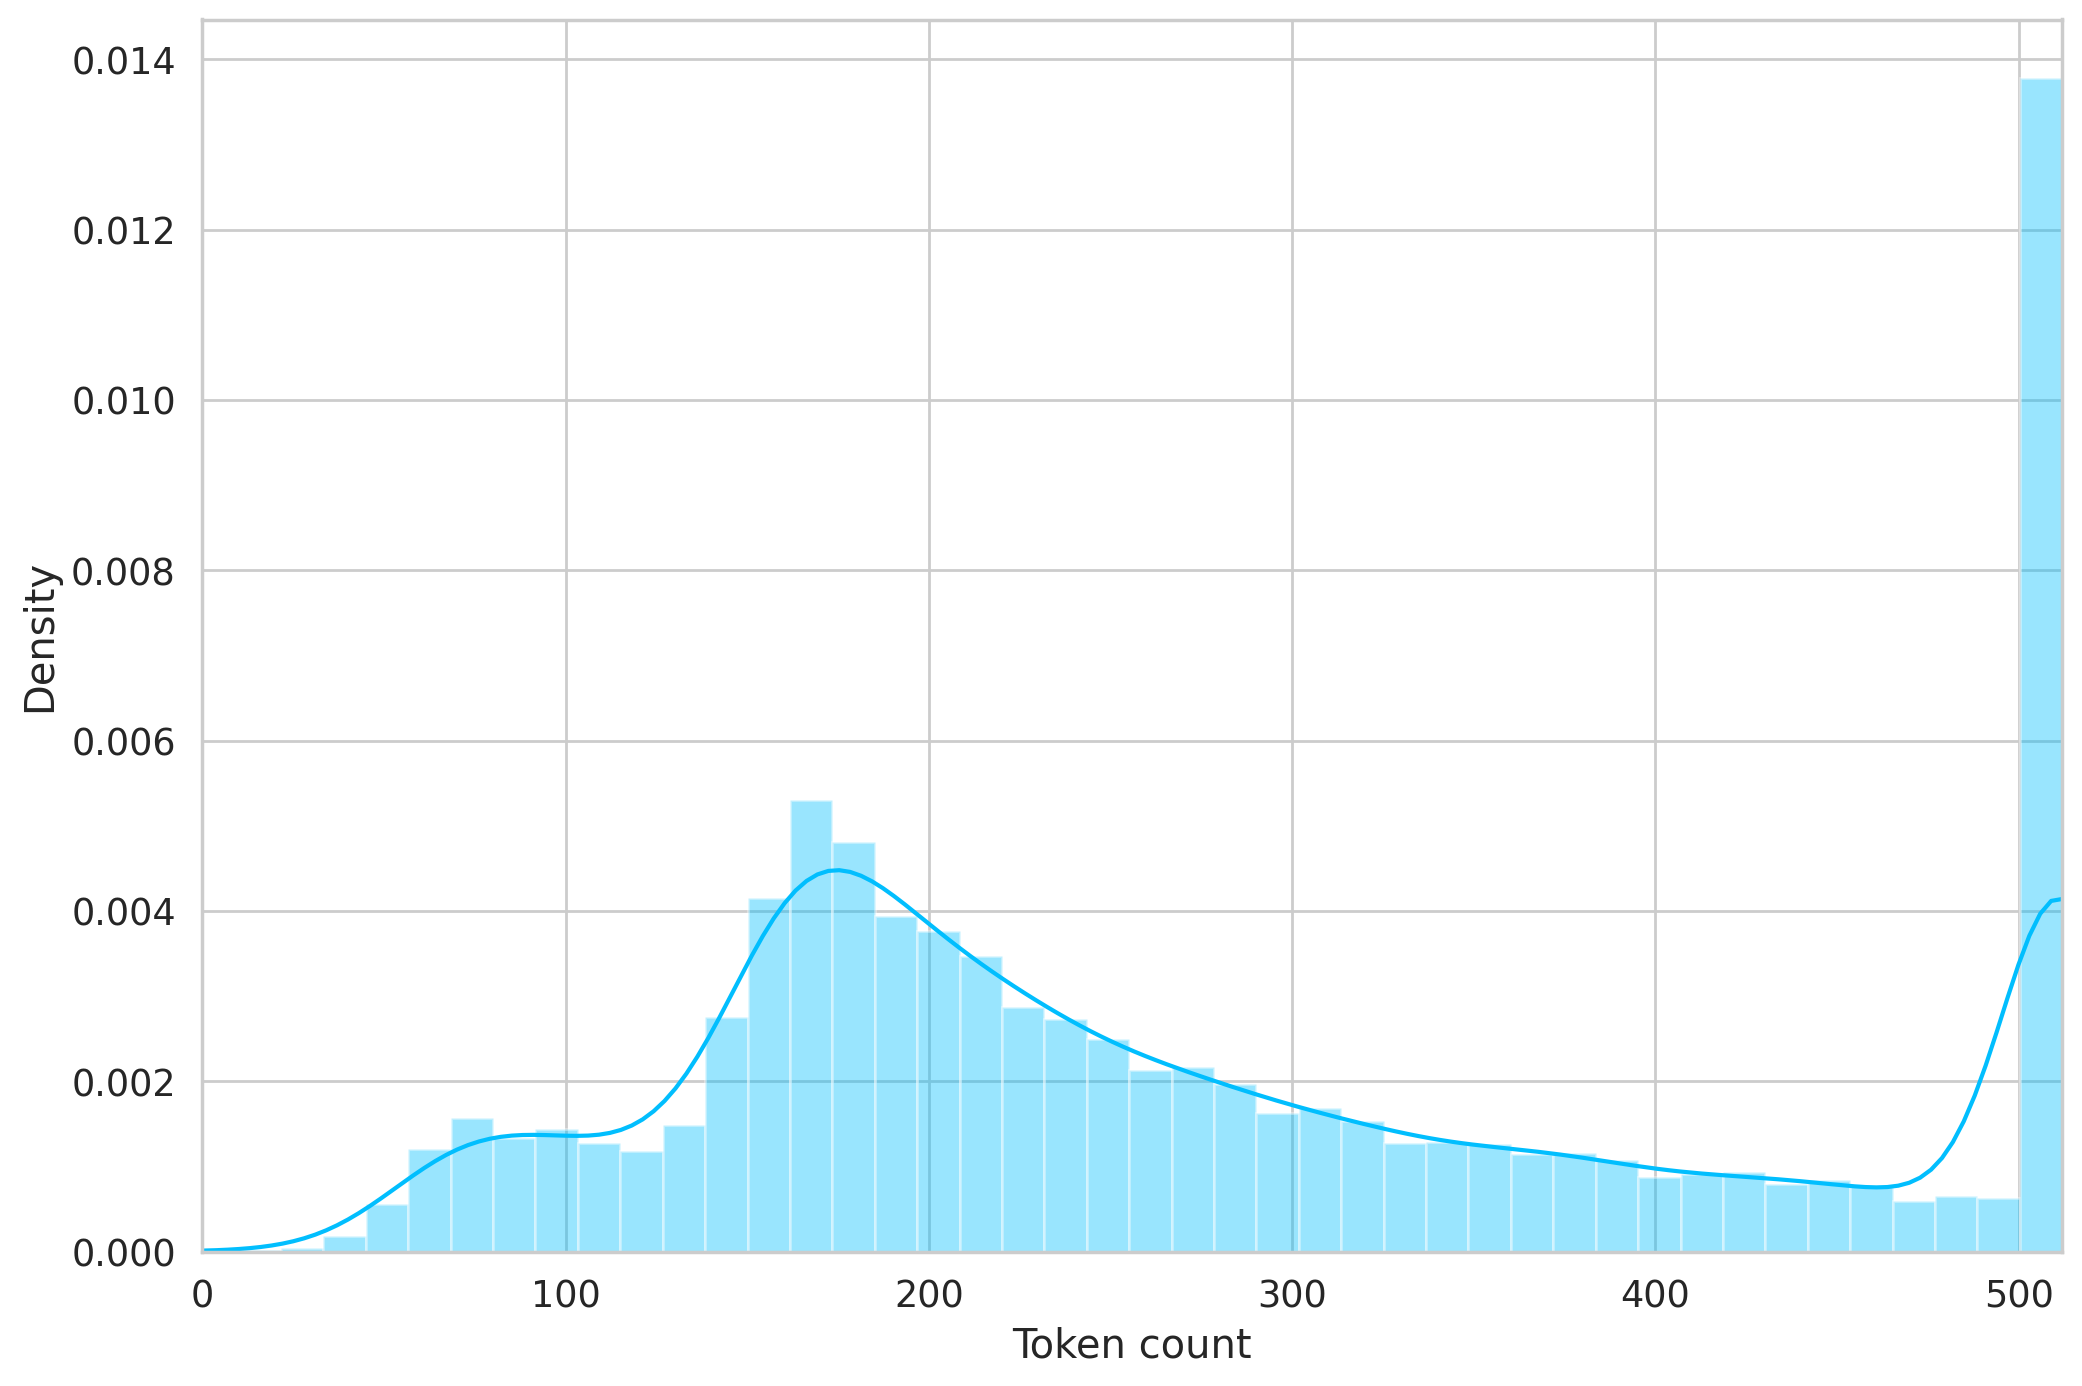

In [ ]:
sns.distplot(token_lens)
plt.xlim([0, 512]);
plt.xlabel('Token count');

In [ ]:
MAX_LEN = 400

In [ ]:
class MovieReviewDataset(Dataset):

  def __init__(self, reviews, targets, tokenizer, max_len):
    self.reviews = reviews
    self.targets = targets
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.reviews)

  def __getitem__(self, item):
    review = str(self.reviews[item])
    target = self.targets[item]

    encoding = self.tokenizer.encode_plus(
      review,
      add_special_tokens=True,
      max_length=self.max_len,
      return_token_type_ids=False,
      padding='max_length',
      return_attention_mask=True,
      return_tensors='pt',
      truncation = True
    )

    return {
      'review_text': review,
      'input_ids': encoding['input_ids'].flatten(),
      'attention_mask': encoding['attention_mask'].flatten(),
      'targets': torch.tensor(target, dtype=torch.long)
    }

%70 for training, and %15 each for validation and testing.

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.3, random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=RANDOM_SEED)

In [ ]:
df_train.shape, df_val.shape, df_test.shape

((35000, 3), (7500, 3), (7500, 3))

In [ ]:
def create_data_loader(df, tokenizer, max_len, batch_size):
  ds = MovieReviewDataset(
    reviews=df.review.to_numpy(),
    targets=df.sentiment_score.to_numpy(),
    tokenizer=tokenizer,
    max_len=max_len
  )

  return DataLoader(
    ds,
    batch_size=batch_size,
    num_workers=2
  )

In [ ]:
BATCH_SIZE = 16

train_data_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader = create_data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader = create_data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

In [ ]:
data = next(iter(train_data_loader))
data.keys()

dict_keys(['review_text', 'input_ids', 'attention_mask', 'targets'])

In [ ]:
print(data['input_ids'].shape)
print(data['attention_mask'].shape)
print(data['targets'].shape)

torch.Size([16, 400])
torch.Size([16, 400])
torch.Size([16])


# Sentiment Classification with BERT

In [ ]:
bert_model = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

In [ ]:
outputs = bert_model(
  input_ids=encoding['input_ids'],
  attention_mask=encoding['attention_mask'],
  return_dict=False
)
last_hidden_state = outputs[0]
pooled_output = outputs[1]

In [ ]:
last_hidden_state.shape

torch.Size([1, 32, 768])

In [ ]:
bert_model.config.hidden_size

768

In [ ]:
pooled_output.shape

torch.Size([1, 768])

In [ ]:
class SentimentClassifier(nn.Module):

  def __init__(self, n_classes):
    super(SentimentClassifier, self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.drop = nn.Dropout(p=0.2)
    self.out = nn.Linear(self.bert.config.hidden_size, n_classes)

  def forward(self, input_ids, attention_mask):
    _, pooled_output = self.bert(
      input_ids=input_ids,
      attention_mask=attention_mask,
      return_dict=False
    )
    output = self.drop(pooled_output)
    return self.out(output)

In [ ]:
class_names = ['negative', 'positive']

In [ ]:
len(class_names)

2

In [ ]:
import torch
torch.cuda.empty_cache()

In [ ]:
model = SentimentClassifier(len(class_names))
model = model.to(device)

In [ ]:
input_ids = data['input_ids'].to(device)
attention_mask = data['attention_mask'].to(device)

print(input_ids.shape) # batch size x seq length
print(attention_mask.shape) # batch size x seq length

torch.Size([16, 400])
torch.Size([16, 400])


Apply softmax function to the outputs to get the predicted probabilities.

In [ ]:
F.softmax(model(input_ids, attention_mask), dim=1)

tensor([[0.5796, 0.4204],
        [0.3419, 0.6581],
        [0.3576, 0.6424],
        [0.5113, 0.4887],
        [0.4719, 0.5281],
        [0.5023, 0.4977],
        [0.4200, 0.5800],
        [0.4696, 0.5304],
        [0.4796, 0.5204],
        [0.4882, 0.5118],
        [0.4254, 0.5746],
        [0.5785, 0.4215],
        [0.4946, 0.5054],
        [0.5055, 0.4945],
        [0.4074, 0.5926],
        [0.5434, 0.4566]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

# Training

In [ ]:
from torch.optim import AdamW
EPOCHS = 10

optimizer = AdamW(model.parameters(), lr=2e-5)
total_steps = len(train_data_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
  optimizer,
  num_warmup_steps=0,
  num_training_steps=total_steps
)

loss_fn = nn.CrossEntropyLoss().to(device)

In [ ]:
def train_epoch(
  model,
  data_loader,
  loss_fn,
  optimizer,
  device,
  scheduler,
  n_examples
):
  model = model.train()

  losses = []
  correct_predictions = 0

  for d in data_loader:
    input_ids = d["input_ids"].to(device)
    attention_mask = d["attention_mask"].to(device)
    targets = d["targets"].to(device)

    outputs = model(
      input_ids=input_ids,
      attention_mask=attention_mask
    )

    _, preds = torch.max(outputs, dim=1)
    loss = loss_fn(outputs, targets)

    correct_predictions += torch.sum(preds == targets)
    losses.append(loss.item())

    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()

  return correct_predictions.double() / n_examples, np.mean(losses)

In [ ]:
def eval_model(model, data_loader, loss_fn, device, n_examples):
  model = model.eval()

  losses = []
  correct_predictions = 0

  with torch.no_grad():
    for d in data_loader:
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      loss = loss_fn(outputs, targets)

      correct_predictions += torch.sum(preds == targets)
      losses.append(loss.item())

  return correct_predictions.double() / n_examples, np.mean(losses)

In [ ]:
import torch

# pick GPU if available, else fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [ ]:
# make sure model is on GPU
model = model.to(device)

In [ ]:
# This copies your completed epoch 10 progress to the "latest" file
!cp "/content/drive/MyDrive/ImdbDataset/bert_checkpoints/checkpoint_epoch10.pth" "/content/drive/MyDrive/ImdbDataset/bert_checkpoints/checkpoint_latest.pth"

In [ ]:
%%time
import os
import torch
import json
from collections import defaultdict

# -------- CONFIG --------
EPOCHS = 10
# This directory in your Drive will store all progress
checkpoint_dir = "/content/drive/MyDrive/ImdbDataset/bert_checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)

# Define file paths
checkpoint_latest = os.path.join(checkpoint_dir, "checkpoint_latest.pth")
best_model_path = os.path.join(checkpoint_dir, "best_model_state.bin")
history_json_path = os.path.join(checkpoint_dir, "history.json")

# -------- INTELLIGENT RESUME LOGIC --------
# Set defaults for a fresh run
start_epoch = 0
best_accuracy = 0.0
history = defaultdict(list)

# Check if a full checkpoint ("the bookmark") exists to resume from
if os.path.exists(checkpoint_latest):
    print(f"Loading checkpoint '{checkpoint_latest}' to resume training.")
    checkpoint = torch.load(checkpoint_latest, map_location=device)

    # Restore the state from the checkpoint
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model_state_dict'])

    if 'optimizer' in globals() and checkpoint.get('optimizer_state_dict'):
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        print("Optimizer state loaded.")

    if 'scheduler' in globals() and scheduler is not None and checkpoint.get('scheduler_state_dict'):
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        print("Scheduler state loaded.")

    history = defaultdict(list, checkpoint['history'])
    best_accuracy = checkpoint['best_accuracy']

    print(f"✅ Resuming training from Epoch {start_epoch + 1}")

# If no checkpoint, check for just the best weights ("the trophy")
elif os.path.exists(best_model_path):
    print(f"No checkpoint found. Loading best weights from '{best_model_path}'.")
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    print("⚠️ Starting from Epoch 1, as only model weights were found, not the full training state.")

else:
    print("🏁 No checkpoint or saved weights found. Starting training from scratch.")


# -------- HELPER FUNCTIONS --------
def save_checkpoint(epoch, history, best_accuracy):
    """Saves a full checkpoint dictionary to resume training."""
    ckpt = {
        'epoch': epoch, # 0-indexed epoch number that was just completed
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if 'optimizer' in globals() else None,
        'scheduler_state_dict': scheduler.state_dict() if ('scheduler' in globals() and scheduler is not None) else None,
        'history': dict(history),
        'best_accuracy': best_accuracy
    }
    # Save a copy for the specific epoch and update the "latest" bookmark
    path_epoch = os.path.join(checkpoint_dir, f"checkpoint_epoch{epoch+1}.pth")
    torch.save(ckpt, path_epoch)
    torch.save(ckpt, checkpoint_latest)

    # Save human-readable history log
    with open(history_json_path, "w") as f:
        json.dump(dict(history), f, indent=2)

    print(f"🔖 Checkpoint saved: {path_epoch} and updated {checkpoint_latest}")


# -------- MAIN TRAINING LOOP --------
try:
    # The loop now starts from 'start_epoch', which is either 0 or the restored value
    for epoch in range(start_epoch, EPOCHS):
        print(f'\nEpoch {epoch + 1}/{EPOCHS}')
        print('-' * 10)

        train_acc, train_loss = train_epoch(
            model,
            train_data_loader,
            loss_fn,
            optimizer,
            device,
            scheduler,
            len(df_train)
        )
        print(f'Train loss {train_loss.item():.4f} accuracy {train_acc.item():.4f}')

        val_acc, val_loss = eval_model(
            model,
            val_data_loader,
            loss_fn,
            device,
            len(df_val)
        )
        print(f'Val   loss {val_loss.item():.4f} accuracy {val_acc.item():.4f}\n')

        # Record metrics as standard Python numbers
        history['train_acc'].append(train_acc.item())
        history['train_loss'].append(train_loss.item())
        history['val_acc'].append(val_acc.item())
        history['val_loss'].append(val_loss.item())

        # Save the "trophy" model if validation accuracy improves
        current_val_acc = val_acc.item()
        if current_val_acc > best_accuracy:
            torch.save(model.state_dict(), best_model_path)
            best_accuracy = current_val_acc
            print(f"🏆 New best model saved (val_acc={best_accuracy:.4f})")

        # Save the "bookmark" checkpoint at the end of every epoch
        save_checkpoint(epoch, history, best_accuracy)

    print("\nTraining complete.")

except KeyboardInterrupt:
    print("\nInterrupted by user — saving final checkpoint before exit...")
    save_checkpoint(epoch, history, best_accuracy)
    raise
except Exception as e:
    print(f"\nAn exception occurred: {e}\nSaving checkpoint before re-raising.")
    save_checkpoint(epoch, history, best_accuracy)
    raise

Loading checkpoint '/content/drive/MyDrive/ImdbDataset/bert_checkpoints/checkpoint_latest.pth' to resume training.
Optimizer state loaded.
Scheduler state loaded.
✅ Resuming training from Epoch 11

Training complete.
CPU times: user 588 ms, sys: 1.01 s, total: 1.6 s
Wall time: 31.4 s


In [ ]:
# 1. Instantiate your model again
model = SentimentClassifier(len(class_names))

# 2. Define the path to your saved model file
best_model_path = "/content/drive/MyDrive/ImdbDataset/bert_checkpoints/best_model_state.bin"

# 3. Load the weights into the model
model.load_state_dict(torch.load(best_model_path))

# 4. Move the model to the GPU
model = model.to(device)

In [ ]:
# Get accuracy and loss on the test set
test_acc, test_loss = eval_model(
  model,
  test_data_loader,
  loss_fn,
  device,
  len(df_test)
)

print(f'Test Loss: {test_loss}')
print(f'Test Accuracy: {test_acc.item()}')

Test Loss: 0.5076491823014825
Test Accuracy: 0.9297333333333334


In [ ]:
import torch.nn.functional as F
import numpy as np

def get_predictions(model, data_loader):
  model = model.eval()

  review_texts = []
  predictions = []
  prediction_probs = []
  real_values = []

  with torch.no_grad():
    for d in data_loader:
      texts = d["review_text"]
      input_ids = d["input_ids"].to(device)
      attention_mask = d["attention_mask"].to(device)
      targets = d["targets"].to(device)

      outputs = model(
        input_ids=input_ids,
        attention_mask=attention_mask
      )
      _, preds = torch.max(outputs, dim=1)

      review_texts.extend(texts)
      predictions.extend(preds)
      real_values.extend(targets)

  predictions = torch.stack(predictions).cpu()
  real_values = torch.stack(real_values).cpu()
  return review_texts, predictions, real_values

              precision    recall  f1-score   support

    negative       0.92      0.94      0.93      3778
    positive       0.93      0.92      0.93      3722

    accuracy                           0.93      7500
   macro avg       0.93      0.93      0.93      7500
weighted avg       0.93      0.93      0.93      7500



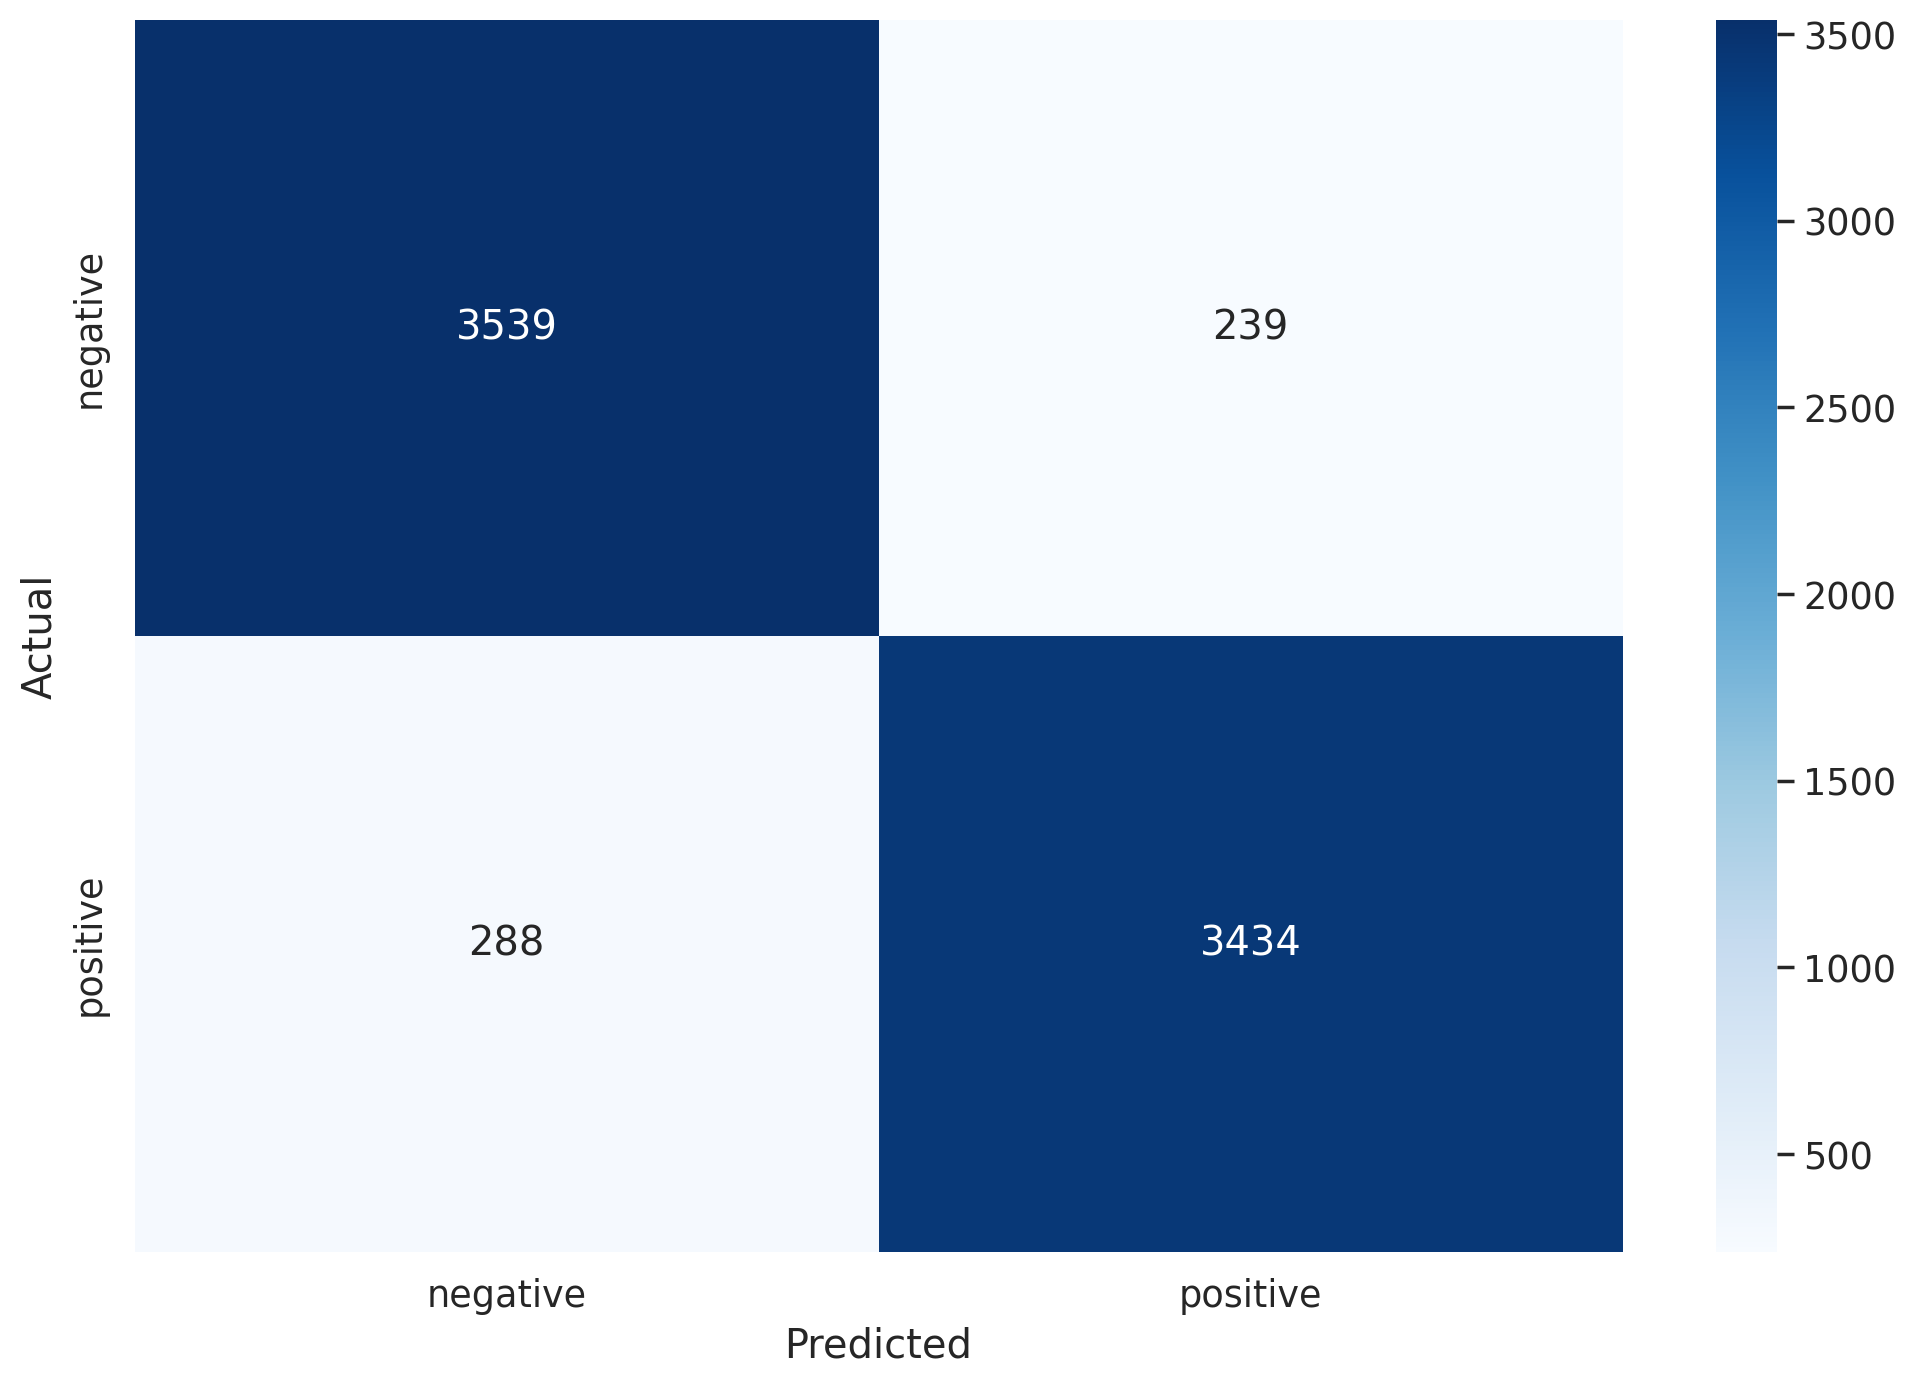

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get the predictions from the test data
y_review_texts, y_pred, y_test = get_predictions(
  model,
  test_data_loader
)

# 2. Print a detailed report with precision, recall, and f1-score
print(classification_report(y_test, y_pred, target_names=class_names))

# 3. Plot a confusion matrix to visualize performance
cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)

sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()